In [1]:
%matplotlib inline

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import scipy as sp
import cartopy.crs as ccrs
from numba import njit, prange
from tqdm.auto import tqdm

/home/astrolander/.generalvenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data = pd.read_csv('sdss_cutout.csv')
data

,RA,DEC,Z,phot_u,phot_g,phot_r,phot_i,phot_z
0,130.089951,52.178097,0.097629,19.854843,18.159964,17.345013,16.930433,16.620535
1,130.173909,52.557767,0.067737,19.250399,17.239248,16.517265,16.083832,15.822161
2,130.081237,52.668188,0.063350,18.680342,17.206959,16.697826,16.362032,16.173033
3,130.291706,52.572373,0.065425,19.726742,17.791235,16.906610,16.495539,16.182104
4,130.013537,52.766588,0.123360,19.386818,17.534359,16.450377,15.943369,15.545097
...,...,...,...,...,...,...,...,...
319953,149.580633,47.033396,0.390038,23.223936,19.346468,17.534588,16.857544,16.351515
319954,150.261929,46.827647,0.204686,20.360432,18.511255,17.276648,16.812563,16.496658
319955,149.937963,46.482358,0.102099,19.087252,17.185118,16.237055,15.844631,15.480799
319956,150.023597,46.260926,0.069142,19.072407,17.949339,17.497790,17.227016,17.132250


## Task 1

Text(0.5, 0, 'redshift')

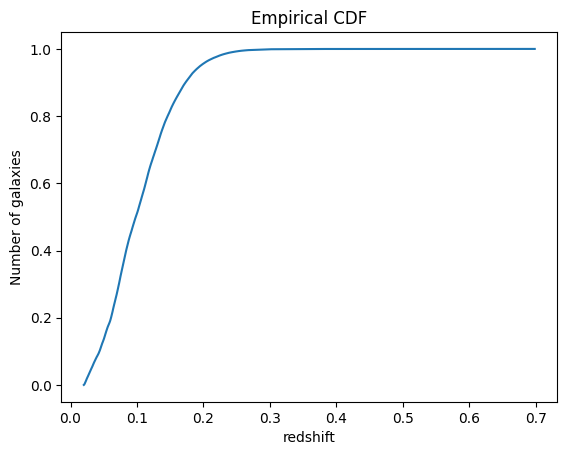

In [4]:
plt.figure()
redshifts = np.sort(data['Z'].values)
plt.plot(redshifts, np.arange(len(redshifts))/len(redshifts))
plt.title('Empirical CDF')
plt.ylabel('Number of galaxies')
plt.xlabel('redshift')

Text(0, 0.5, 'phot_r')

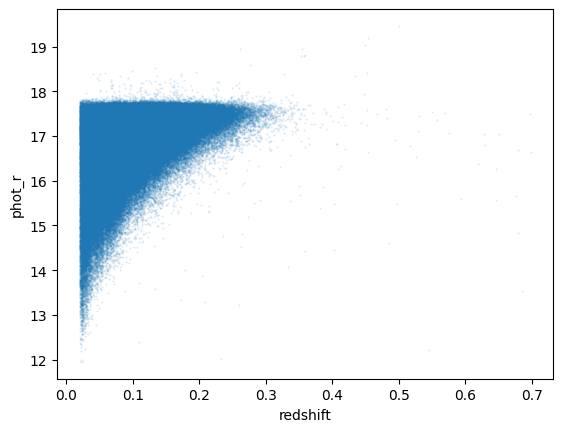

In [5]:
plt.figure()
plt.scatter(data['Z'], data['phot_r'], s=0.5, alpha=0.1)
plt.xlabel('redshift')
plt.ylabel('phot_r')

In [6]:
data_cut = data[(data['Z'] > 0.08) & (data['Z'] < 0.12)].copy()

Text(0, 0.5, 'phot_r')

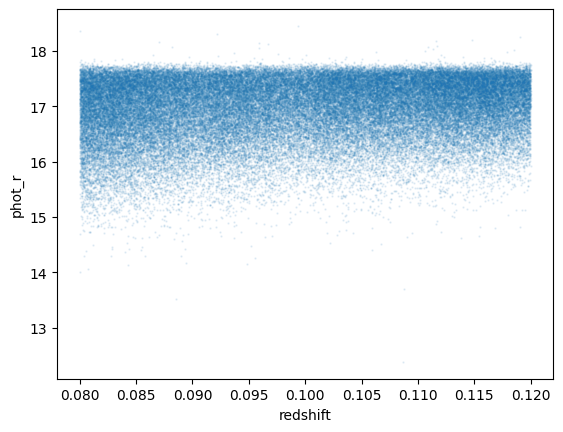

In [7]:
plt.figure()
plt.scatter(data_cut['Z'], data_cut['phot_r'], s=0.5, alpha=0.1)
plt.xlabel('redshift')
plt.ylabel('phot_r')

## Task 2

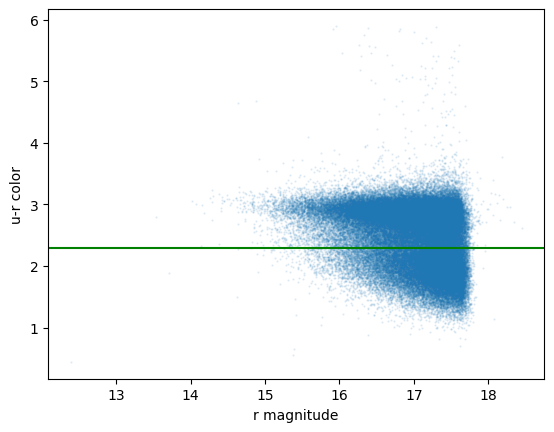

In [8]:
plt.figure()
plt.scatter(data_cut['phot_r'], data_cut['phot_u']-data_cut['phot_r'], s=0.5, alpha=0.1)
plt.xlabel('r magnitude')
plt.ylabel('u-r color')
plt.axhline(2.3, color='green')

In [9]:
data_cut['u-r'] = data_cut['phot_u'] - data_cut['phot_r']

In [10]:
red = data_cut[data_cut['u-r'] > 2.3].copy()
blue = data_cut[data_cut['u-r'] <= 2.3].copy()

## Task 3

In [11]:
print(np.mean(red['phot_r']), '+-', np.std(red['phot_r']))
print(np.mean(blue['phot_r']), '+-', np.std(blue['phot_r']))

16.884902132896993 +- 0.5532295368731545
17.148581973026662 +- 0.4317605611301002


In [12]:
sp.stats.bootstrap((red['phot_r'].to_numpy(),), np.mean, vectorized=False, n_resamples=1000, confidence_level=0.95, method='percentile')

BootstrapResult(confidence_interval=ConfidenceInterval(low=np.float64(16.880542306097706), high=np.float64(16.8889994398895)), bootstrap_distribution=array([16.88287113, 16.8839672 , 16.88400514, 16.88719865, 16.89106525,
       16.88461561, 16.88584911, 16.88316305, 16.88513338, 16.88756627,
       16.8857657 , 16.88447188, 16.8865618 , 16.8863935 , 16.8816628 ,
       16.88181689, 16.88467776, 16.88398084, 16.88218615, 16.88715079,
       16.88623764, 16.88237378, 16.88446141, 16.881309  , 16.88472081,
       16.88708669, 16.88386546, 16.88483763, 16.88830295, 16.88329805,
       16.88433969, 16.88453776, 16.88253673, 16.88434742, 16.88251833,
       16.89026201, 16.8896393 , 16.88498948, 16.88421297, 16.88428406,
       16.88308968, 16.88291369, 16.88412326, 16.88548097, 16.88448251,
       16.88515015, 16.88755066, 16.88455371, 16.88613169, 16.88312982,
       16.88445889, 16.88841126, 16.88422209, 16.88629657, 16.88762353,
       16.88503802, 16.88354804, 16.88859295, 16.88358661,

In [13]:
sp.stats.bootstrap((blue['phot_r'].to_numpy(),), np.mean, vectorized=False, n_resamples=1000, confidence_level=0.95, method='percentile')

BootstrapResult(confidence_interval=ConfidenceInterval(low=np.float64(17.143464230851475), high=np.float64(17.153408430776366)), bootstrap_distribution=array([17.14994894, 17.14783203, 17.14976816, 17.14979206, 17.14669917,
       17.15171364, 17.14890106, 17.14646116, 17.14939902, 17.14684188,
       17.14726221, 17.14356441, 17.14662474, 17.14905435, 17.14360652,
       17.15303103, 17.14621886, 17.14735357, 17.15198428, 17.14433853,
       17.15066826, 17.1443952 , 17.14902901, 17.14640404, 17.15394581,
       17.14972303, 17.15341556, 17.14773686, 17.14581352, 17.14618012,
       17.14484525, 17.14834275, 17.14784097, 17.14741733, 17.14853702,
       17.15127036, 17.15091569, 17.15105329, 17.15082997, 17.14793442,
       17.1479189 , 17.14571604, 17.1479688 , 17.14809161, 17.14846084,
       17.14874307, 17.14753457, 17.14704959, 17.14960702, 17.14688483,
       17.14834006, 17.14656843, 17.14981638, 17.15116031, 17.1488752 ,
       17.15167944, 17.14867993, 17.14684634, 17.1512811

In [12]:
def z_alpha(a):
    return sp.stats.norm.ppf((1+a)/2)

In [13]:
z_alpha(0.95)

np.float64(1.959963984540054)

In [14]:
conf_interval = z_alpha(0.95)*np.std(red['phot_r'])/np.sqrt(len(red['phot_r']))

In [15]:
print(conf_interval)
print(conf_interval/z_alpha(0.95))
print(np.mean(red['phot_r'])-conf_interval, np.mean(red['phot_r'])+conf_interval)

0.0044026743807326785
0.00224630371550723
16.88049945851626 16.889304807277725


In [16]:
np.std(red['phot_r'])/np.sqrt(len(red['phot_r']))

np.float64(0.0022463037155072297)

## Task 5

In [17]:
# fig = plt.figure(figsize=(10, 5))
# # Define Mollweide projection
# ax = plt.axes(projection=ccrs.Mollweide(180))
# # ax.stock_img()
# ax.gridlines()
# ax.scatter(red['RA'], red['DEC'], s=0.5, alpha=0.1, transform=ccrs.PlateCarree())

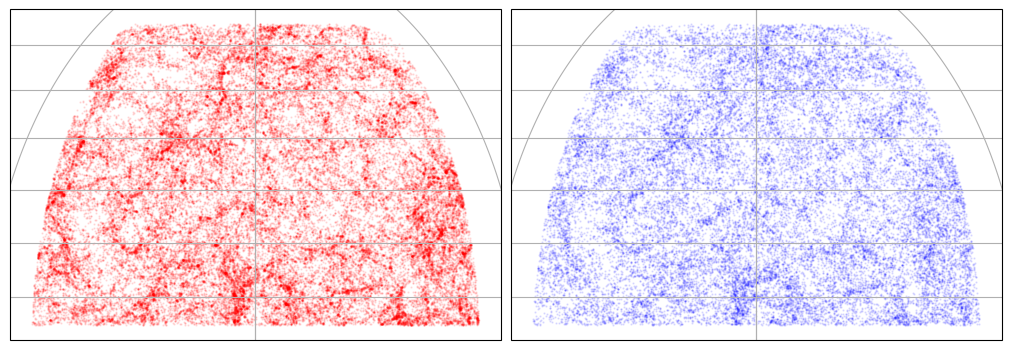

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(10, 15), subplot_kw={'projection': ccrs.Mollweide(180)},
                        layout='constrained')

ax[0].gridlines()
ax[0].scatter(red['RA'], red['DEC'], s=0.5, alpha=0.1, transform=ccrs.PlateCarree(), color='red')

ax[1].gridlines()
ax[1].scatter(blue['RA'], blue['DEC'], s=0.5, alpha=0.1, transform=ccrs.PlateCarree(), color='blue')


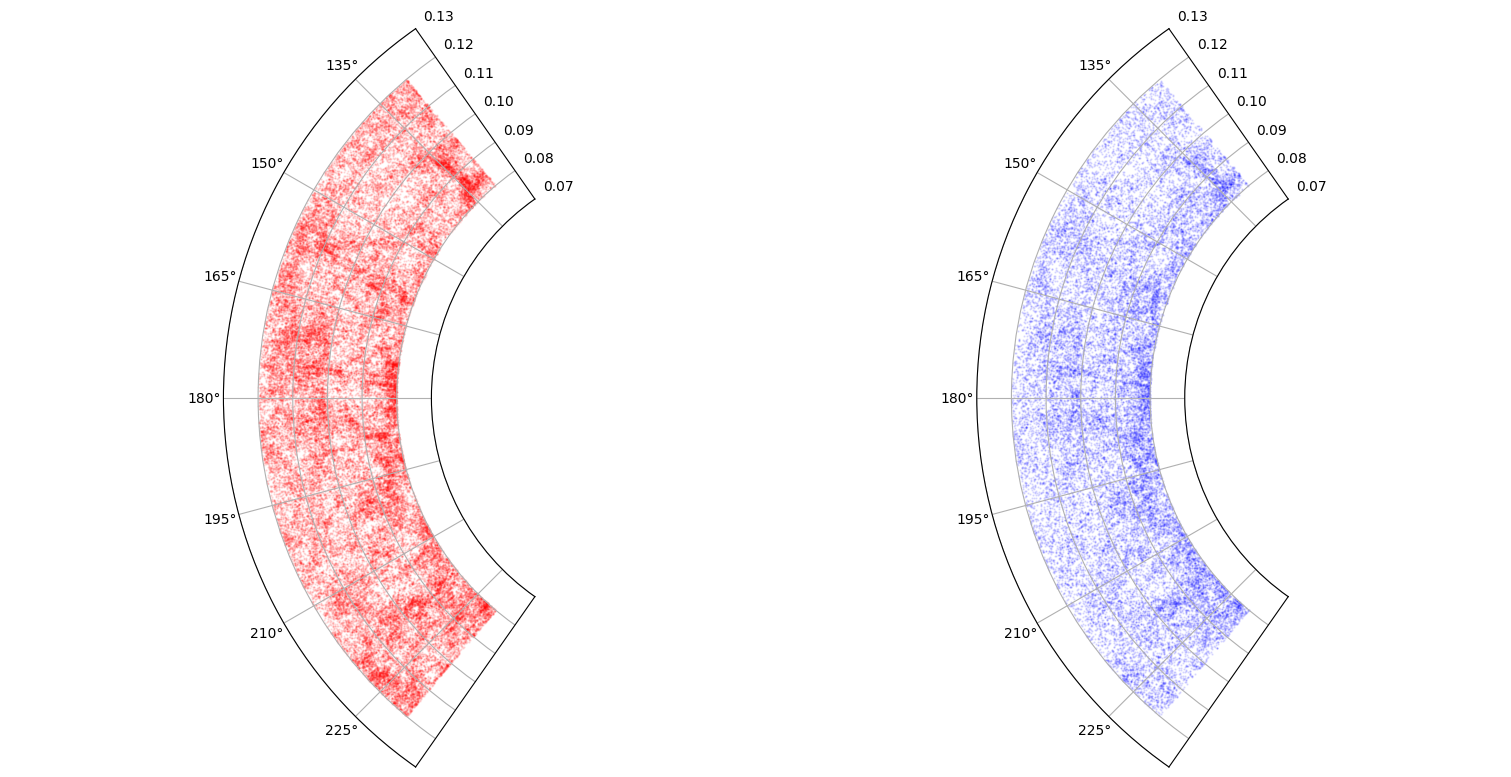

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(15, 20), subplot_kw={'projection': 'polar'},
                        layout='constrained')
ax[0].scatter(red['RA']*np.pi/180, red['Z'], s=0.5, alpha=0.1, color='red')
ax[1].scatter(blue['RA']*np.pi/180, blue['Z'], s=0.5, alpha=0.1, color='blue')
# ax[1].scatter(data_cut['RA']*np.pi/180, data_cut['Z'], s=0.5, alpha=0.1, color='black')

ax[0].set_rmax(0.13)
ax[0].set_rmin(0.07)  # Change the radial axis to only go from 1 to 2
ax[0].set_rorigin(0)  # Set the origin of the radial axis to 0
ax[0].set_thetamin(125)
ax[0].set_thetamax(235)


ax[1].set_rmax(0.13)
ax[1].set_rmin(0.07)  # Change the radial axis to only go from 1 to 2
ax[1].set_rorigin(0)  # Set the origin of the radial axis to 0
ax[1].set_thetamin(125)
ax[1].set_thetamax(235)


In [20]:
# plt.scatter(red['RA']*2*np.pi/180, red['DEC'], s=0.5, alpha=0.1, color='red')
# plt.scatter(blue['RA']*2*np.pi/180, blue['DEC'], s=0.5, alpha=0.1, color='blue')

## Computing the two-point correlation function

Uniform distribution on the cartesian ra/dec grid is not uniform on the sphere. To demonstrate this we created a function which can generate uniformly distributed objects either on cartesian grid or on sperical grid.

In [151]:
def unirand_field(xmin, xmax, ymin, ymax, N=100, sphere=True, unit='rad'):
    if sphere:
        return unirand_sphere(xmin, xmax, ymin, ymax, N, unit)
    else:
        x = np.random.rand(N)*(xmax - xmin) + xmin
        y = np.random.rand(N)*(ymax - ymin) + ymin
        return x, y

We followed this method of generating uniform distribution on spere: https://github.com/CorySimon/CorySimon.github.io/blob/master/_posts/articles/2015-02-27-uniformdistn-on-sphere.md

Changes we made:
1) Add limits to make it possible to cover just part of the sphere.
2) 

In [163]:
def unirand_sphere(ramin, ramax, decmin, decmax, N=100, unit='rad'):
    if unit=='deg':
        ramin, ramax, decmin, decmax = np.deg2rad([ramin, ramax, decmin, decmax])
    elif unit!='rad':
        raise ValueError("unit should be 'rad' or 'dec'")

    ra = np.random.rand(N)*(ramax-ramin) + ramin
    dec_rand_min = (1-np.sin(decmin))/2.
    dec_rand_max = (1-np.sin(decmax))/2.
    dec_rand = np.random.rand(N)*(dec_rand_max - dec_rand_min) + dec_rand_min
    dec = np.pi/2 - np.arccos(1 - 2*dec_rand)

    if unit=='deg':
        ra, dec = np.rad2deg([ra, dec])

    return ra, dec

    

In [135]:
rand_ra, rand_dec = unirand_field(130, 230, 5, 65, len(data_cut), unit='deg', sphere=False)

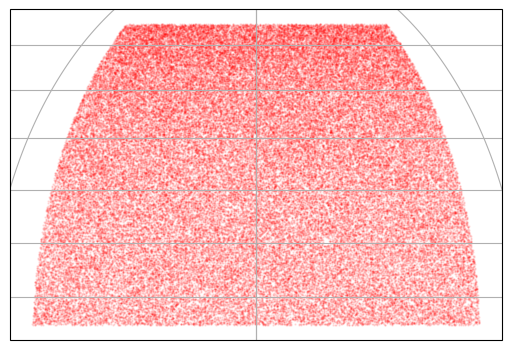

In [136]:
fig, ax = plt.subplots(1, 1, figsize=(5, 8), subplot_kw={'projection': ccrs.Mollweide(180)},
                        layout='constrained')

ax.gridlines()
ax.scatter(rand_ra, rand_dec, s=0.5, alpha=0.1, transform=ccrs.PlateCarree(), color='red')

In [137]:
rand_ra, rand_dec = unirand_field(130, 230, 5, 65, len(data_cut), unit='deg')

0.08726856481463119 1.134426904530914


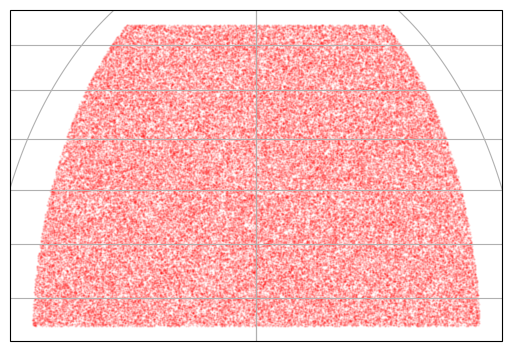

In [138]:
fig, ax = plt.subplots(1, 1, figsize=(5, 8), subplot_kw={'projection': ccrs.Mollweide(180)},
                        layout='constrained')

ax.gridlines()
ax.scatter(rand_ra, rand_dec, s=0.5, alpha=0.1, transform=ccrs.PlateCarree(), color='red')

In [139]:
bins = np.geomspace(0.003,0.3,11)

In [140]:
@njit(parallel=True)
def spat_corr(x, y, bins):
    n = np.zeros(len(bins))
    for i in prange(len(x)):
        for j in prange(len(y)):
            sep = dist_sphere(x[i], y[j])
            for k, b in enumerate(bins):
                if sep < b:
                    n[k] = n[k] + 1
                    break
    return n

@njit(parallel=True)
def spat_spec(x, bins):
    n = np.zeros(len(bins))
    for i in prange(len(x)):
        for j in prange(i+1, len(x)):
            sep = dist_sphere(x[i], x[j])
            for k, b in enumerate(bins):
                if sep < b:
                    n[k] = n[k] + 1
                    break
    return n

@njit()
def dist_cart(first, second):
    return np.sqrt((first[0]-second[0])**2 + (first[1]-second[1])**2)

@njit()
def dist_sphere(A, B):
    '''
    assumes that every coordinate is [RA(rad), DEC(rad)]
    '''
    cos_theta = np.sin(A[1])*np.sin(B[1]) + np.cos(A[1])*np.cos(B[1])*np.cos(A[0]-B[0])
    return np.arccos(cos_theta)

In [141]:
red_np = np.array([red['RA'].values, red['DEC'].values]).T * np.pi/180.
red_np

array([[2.27049796, 0.91067958],
       [2.28050003, 0.87391945],
       [2.28951282, 0.87932566],
       ...,
       [2.61353364, 0.80825221],
       [2.6099061 , 0.81114086],
       [2.61691112, 0.81127019]], shape=(60656, 2))

In [142]:
red_small_subset = red_np[np.random.randint(0, len(red_np), 10)]

In [143]:
spat_corr(red_small_subset, red_small_subset, bins)

array([ 9.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  2.,  4., 12.])

In [144]:
spat_corr(red_small_subset, red_small_subset, bins)

array([ 9.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  2.,  3., 12.])

In [145]:
spat_spec(red_small_subset, bins)

array([0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 6.])

In [146]:
spat_spec(red_small_subset, bins)

array([0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 6.])

In [45]:
spec1 = spat_corr(red_np, red_np, bins)

In [46]:
spec2 = spat_spec(red_np, bins)

In [171]:
def tp_corr_func_LS(points, bins, M=None, rand_field=None, RR=None):
    '''
    points: ndarray
        2D array, each row is ra-dec coordinate (in rad)
    bins: ndarray
        distance bins for 2D-correlation func
    M: None or int, optional, default=None
        number of points in uniform distribution
    '''
    N = len(points)
    # N if M is None, else M
    M = M or N
    if rand_field is None:
        ra_min, dec_min = np.min(points, axis=0)
        ra_max, dec_max = np.max(points, axis=0)
        rand_ra, rand_dec = unirand_field(ra_min, ra_max, dec_min, dec_max, M)
        rand_field = np.array([rand_ra, rand_dec]).T
    if RR is None:
        RR = spat_spec(rand_field, bins)
    DD = spat_spec(points, bins)
    RD = spat_corr(rand_field, points, bins)

    corr = 1 + M*(M-1)*DD/(N*(N-1)*RR) - (M-1)*RD/(N*RR)
    return corr 

In [172]:
rand_ra, rand_dec = unirand_field(130, 230, 5, 65, len(data_cut), unit='deg')
rand_field = np.array([rand_ra, rand_dec]).T
RR = spat_spec(rand_field, bins)

In [173]:
corr_red2 = tp_corr_func_LS(red_np, bins, M=len(rand_field), rand_field=rand_field, RR=RR)

In [175]:
blue_np = np.array([blue['RA'].values, blue['DEC'].values]).T * np.pi/180.

In [176]:
corr_blue2 = tp_corr_func_LS(blue_np, bins, M=len(rand_field), rand_field=rand_field, RR=RR)

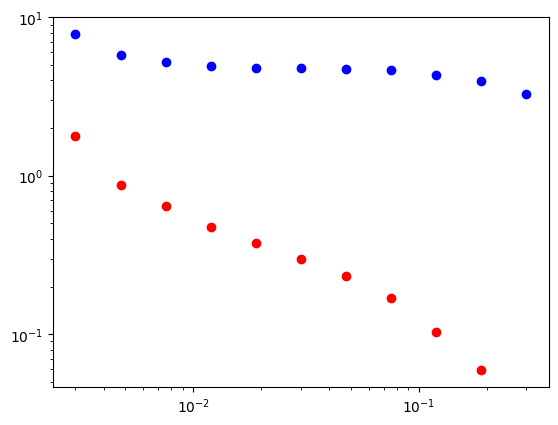

In [177]:
fig, ax = plt.subplots()
ax.plot(bins, corr_red, 'ro')
ax.plot(bins, corr_red2, 'bo')
ax.set_xscale('log')
ax.set_yscale('log')

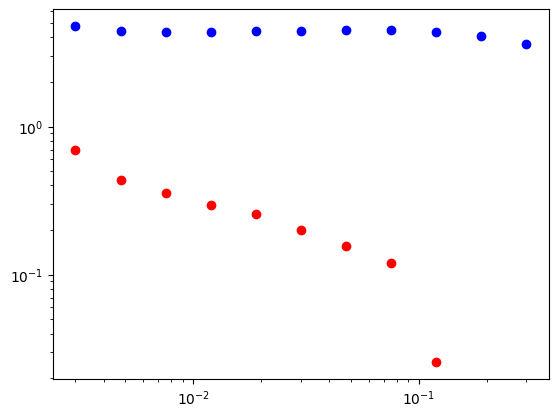

In [178]:
fig, ax = plt.subplots()
ax.plot(bins, corr_blue, 'ro')
ax.plot(bins, corr_blue2, 'bo')
ax.set_xscale('log')
ax.set_yscale('log')

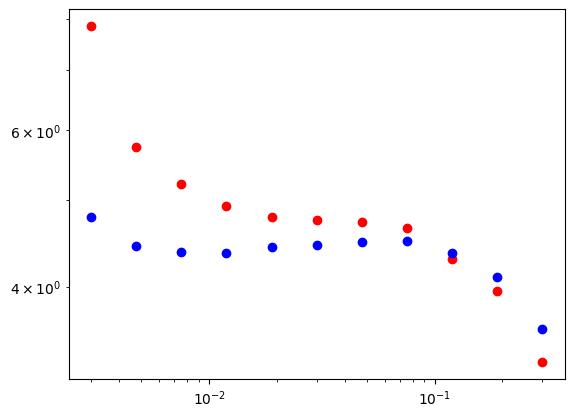

In [179]:
fig, ax = plt.subplots()
ax.plot(bins, corr_red2, 'ro')
ax.plot(bins, corr_blue2, 'bo')
ax.set_xscale('log')
ax.set_yscale('log')

In [187]:
def jacknife(data, statistics, sub_n=None, itn=10, args=(), **kwargs):
    rng = np.random.default_rng()
    N = len(data)
    sub_n = sub_n or N/10

    if not isinstance(sub_n, int):
        try:
            sub_n = int(sub_n)
        except ValueError:
            print("Number of elements in subsample should be integer!")

    if sub_n > N:
        raise ValueError("Subsample should be smaller than full sample!")
            
    if not isinstance(args, tuple):
        args = (args,)
        
    res = []
    for i in tqdm(range(itn)):
        subsample = rng.choice(data, sub_n, replace=False)
        res.append(statistics(subsample, *args, **kwargs))
    raw_var = np.var(res, ddof=1, axis=0)
    sigma = np.sqrt(raw_var)
    av = np.mean(res, axis=0)
    return av, sigma

In [184]:
test_data = np.arange(101)
def my_mean(data, add, mult=1):
    return np.mean(data)*mult + add

In [39]:
jacknife(test_data, my_mean, args=0, itn=100, sub_n=10)

100%|███████████████████████████████████████| 100/100 [00:00<00:00, 6863.31it/s]


(np.float64(51.098), np.float64(64.19563192319231))

In [197]:
corr_red_j, corr_red_err = jacknife(red_np, tp_corr_func_LS, sub_n=1000, args=(bins,), itn=10, M=len(rand_field), rand_field=rand_field, RR=RR)

100%|███████████████████████████████████████████| 10/10 [00:18<00:00,  1.82s/it]


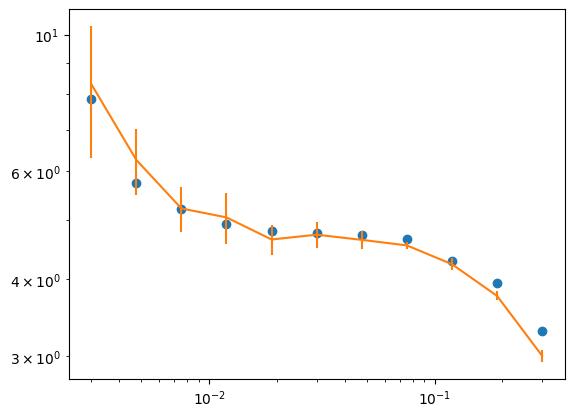

In [198]:
fig, ax = plt.subplots()
ax.plot(bins, corr_red2, 'o')
# ax.plot(bins, corr_red, 'o')

ax.errorbar(bins, corr_red_j, yerr=corr_red_err)
ax.set_xscale('log')
ax.set_yscale('log')
# plt.plot(corr_red, 'o')

In [195]:
corr_blue_j, corr_blue_err = jacknife(blue_np, tp_corr_func_LS, sub_n=1000, args=(bins,), itn=10, M=len(rand_field), rand_field=rand_field, RR=RR)

100%|███████████████████████████████████████████| 10/10 [00:18<00:00,  1.81s/it]


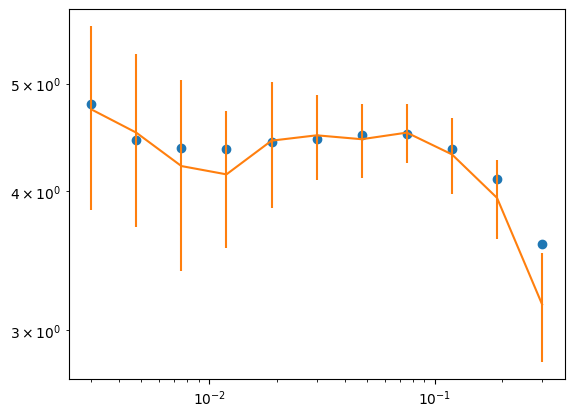

In [196]:
fig, ax = plt.subplots()
ax.plot(bins, corr_blue2, 'o')
ax.errorbar(bins, corr_blue_j, yerr=np.sqrt(corr_blue_err))
ax.set_xscale('log')
ax.set_yscale('log')

In [44]:
rng = np.random.default_rng(0)
print(rng.choice(test_data, 4, replace=False))

[27 51 83 63]
